In [1]:
#--Import crucial libraies. --#
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
#-- Import files and export folder. --#
input_pattern =  '../Processed/roads_*.csv'
output_dir = '../Figures'

In [14]:
all_files = glob.glob(input_pattern)
if not all_files:
    print("Cannot find any file roads_*.csv!")
else:
    df_list = []
    for f in all_files:
        temp_df = pd.read_csv(f, low_memory=False)
        df_list.append(temp_df)
    
    df = pd.concat(df_list, ignore_index=True)

    garbage_values = ['Missing Data', 'unknown', 'Unknown', 'nan', 'none', ' ', '0'] 
    df_cleaned = df.replace(garbage_values, np.nan)

In [15]:
# --- SHOWCASE 1: BẢNG THỐNG KÊ CHI TIẾT (Missing Data Table) ---
missing_counts = df_cleaned.isnull().sum()
missing_pct = (missing_counts / len(df_cleaned) * 100).round(2)
    
missing_table = pd.DataFrame({
    'Column Name': missing_counts.index,
    'Total Missing': missing_counts.values,
    'Percentage (%)': missing_pct.values
})
report_table = missing_table[missing_table['Total Missing'] > 0].sort_values(by='Percentage (%)', ascending=False)
    
print("\n--- TALE OF SUMMARY MISSING VALUE ---")
print(report_table.to_string(index=False))
#-- Print the figure in folder Figures. --#
report_table.to_csv(os.path.join(output_dir, 'roads_missing_summary.csv'), index=False)


--- TALE OF SUMMARY MISSING VALUE ---
Column Name  Total Missing  Percentage (%)
 declared_r          16083           27.75
 movement_t            100            0.17
 local_road             12            0.02


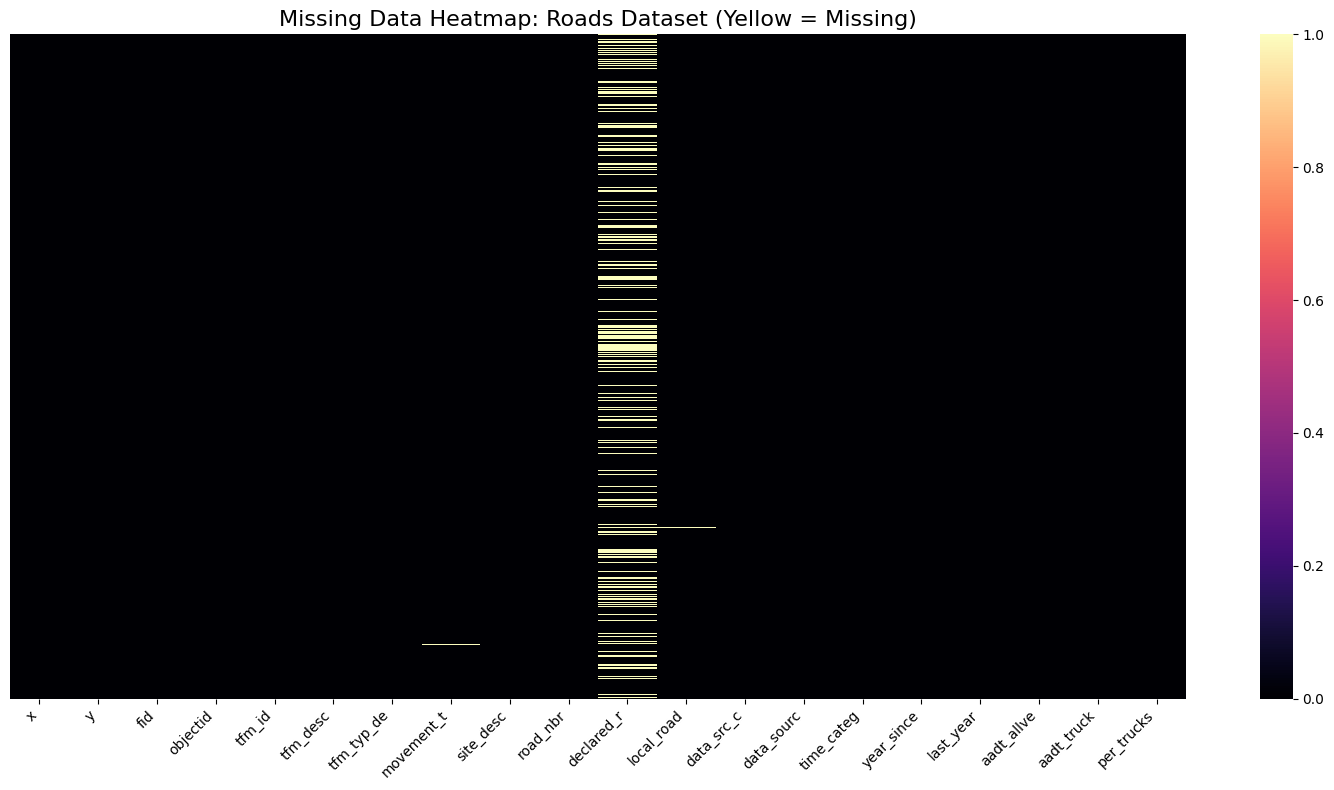


Save figures in folder ../Figures/roads_missing_summary.csv
Saved at: ../Figures/roads_missing_heatmap.png


In [16]:
#-- Missing Data Heatmap. --#
plt.figure(figsize=(15, 8))
sns.heatmap(df_cleaned.isnull(), yticklabels=False, cbar=True, cmap='magma')
    
plt.title('Missing Data Heatmap: Roads Dataset (Yellow = Missing)', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
    
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'roads_missing_heatmap.png'), dpi=300)
plt.show()

print(f"\nSave figures in folder {output_dir}/roads_missing_summary.csv")
print(f"Saved at: {output_dir}/roads_missing_heatmap.png")